## Section 0: Grade-only reframing (5 kelas)

Percobaan reframing dari 30 kelas IOTN-DHC (`02_yolo_rf.ipynb`) jadi **5 kelas Grade** (`1`-`5`) — kode diringkas ke digit Grade-nya saja (`2a`,`2b`,...,`2g` -> `Grade 2`, dst). Tujuannya: kelas jauh lebih seimbang (rasio ~3:1, bukan ~91:1) dan langsung actionable secara klinis (Grade 1-2 = tidak perlu perawatan, 3 = borderline, 4-5 = perlu perawatan). Detail format YOLO & alasan desain lain sudah dijelaskan di `02_yolo_rf.ipynb`, di sini tidak diulang.

## Section 1: Setup

In [1]:
%pip install -q ultralytics


Note: you may need to restart the kernel to use updated packages.


In [3]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
from ultralytics import YOLO
import shutil


In [4]:
DATA_ROOT = Path("/Users/benediktaaa/Documents/AML/dental-malocclusion/Dataset/Malocclusion-Data-processed")
SPLITS = ["train", "valid", "test"]

IMAGES_DIRS = {split: DATA_ROOT / split for split in SPLITS}
ANNOTATION_FILES = {split: DATA_ROOT / split / "_annotations.coco.json" for split in SPLITS}


In [6]:
coco_data = {}
for split in SPLITS:
    with open(ANNOTATION_FILES[split], "r") as f:
        coco_data[split] = json.load(f)

for split in SPLITS:
    d = coco_data[split]
    print(f"[{split}] images={len(d['images'])}, annotations={len(d['annotations'])}")


[train] images=470, annotations=1067
[valid] images=94, annotations=204
[test] images=62, annotations=146


In [7]:
# kategori asli (30 kode IOTN, exclude placeholder root Roboflow)
categories_raw = coco_data["train"]["categories"]
categories = [c for c in categories_raw if c.get("supercategory") != "none"]
category_id_to_name = {c["id"]: c["name"] for c in categories}

def get_image_path(split: str, image_record: dict) -> Path:
    return IMAGES_DIRS[split] / image_record["file_name"]

image_to_anns = {}
for split in SPLITS:
    idx = {}
    for a in coco_data[split]["annotations"]:
        idx.setdefault(a["image_id"], []).append(a)
    image_to_anns[split] = idx

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Menggunakan device:", device)


Menggunakan device: mps


## Section 2: Remap 30 kode -> 5 Grade

Aturan: digit pertama kode = Grade-nya (`1`, `2a`, `3f`, `4t`, `5p` -> `1`, `2`, `3`, `4`, `5`). Kode `1` tidak punya sub-huruf jadi langsung Grade 1.

In [10]:
GRADE_NAMES = [f"Grade {i}" for i in range(1, 6)]
category_id_to_grade = {cid: f"Grade {name[0]}" for cid, name in category_id_to_name.items()}

grade_to_yolo_id = {g: i for i, g in enumerate(GRADE_NAMES)}
yolo_id_to_grade = {i: g for g, i in grade_to_yolo_id.items()}

print(category_id_to_grade)


{1: 'Grade 1', 2: 'Grade 2', 3: 'Grade 2', 4: 'Grade 2', 5: 'Grade 2', 6: 'Grade 2', 7: 'Grade 2', 8: 'Grade 2', 9: 'Grade 3', 10: 'Grade 3', 11: 'Grade 3', 12: 'Grade 3', 13: 'Grade 3', 14: 'Grade 3', 15: 'Grade 4', 16: 'Grade 4', 17: 'Grade 4', 18: 'Grade 4', 19: 'Grade 4', 20: 'Grade 4', 21: 'Grade 4', 22: 'Grade 4', 23: 'Grade 4', 24: 'Grade 4', 25: 'Grade 5', 26: 'Grade 5', 27: 'Grade 5', 28: 'Grade 5', 29: 'Grade 5', 30: 'Grade 5'}


In [11]:
# cek distribusi Grade per split -> harus jauh lebih seimbang dibanding 30 kelas asli
grade_counts = pd.DataFrame({
    split: Counter(category_id_to_grade[a["category_id"]] for a in coco_data[split]["annotations"])
    for split in SPLITS
}).reindex(GRADE_NAMES).fillna(0).astype(int)
grade_counts["total"] = grade_counts[SPLITS].sum(axis=1)
grade_counts


,train,valid,test,total
Grade 1,132,24,20,176
Grade 2,238,45,33,316
Grade 3,266,45,32,343
Grade 4,329,62,44,435
Grade 5,102,28,17,147


## Section 3: Konversi ke format YOLO

In [12]:
YOLO_ROOT = Path("data/rf_yolo_grade")  # folder beda dari data/rf_yolo (30 kelas), biar nggak ketiban
YOLO_IMAGES = {split: YOLO_ROOT / "images" / split for split in SPLITS}
YOLO_LABELS = {split: YOLO_ROOT / "labels" / split for split in SPLITS}

for split in SPLITS:
    YOLO_IMAGES[split].mkdir(parents=True, exist_ok=True)
    YOLO_LABELS[split].mkdir(parents=True, exist_ok=True)


In [13]:
def convert_annotations_to_yolo_lines(anns, img_w, img_h):
    lines = []
    for ann in anns:
        x, y, w, h = ann["bbox"]
        yolo_id = grade_to_yolo_id[category_id_to_grade[ann["category_id"]]]
        x_center = (x + w / 2) / img_w
        y_center = (y + h / 2) / img_h
        lines.append(f"{yolo_id} {x_center:.6f} {y_center:.6f} {w / img_w:.6f} {h / img_h:.6f}")
    return lines


def build_yolo_dataset(split: str):
    copied, skipped = 0, 0
    for img_record in tqdm(coco_data[split]["images"], desc=f"Convert {split}"):
        src_path = get_image_path(split, img_record)
        if not src_path.exists():
            skipped += 1
            continue

        dst_img_path = YOLO_IMAGES[split] / img_record["file_name"]
        dst_label_path = YOLO_LABELS[split] / (Path(img_record["file_name"]).stem + ".txt")
        shutil.copy(src_path, dst_img_path)

        anns = image_to_anns[split].get(img_record["id"], [])
        lines = convert_annotations_to_yolo_lines(anns, img_record["width"], img_record["height"])
        with open(dst_label_path, "w") as f:
            f.write("\n".join(lines))
        copied += 1
    print(f"[{split}] copied={copied}, skipped={skipped}")


for split in SPLITS:
    build_yolo_dataset(split)


Convert train:   0%|          | 0/470 [00:00<?, ?it/s]

[train] copied=470, skipped=0


Convert valid:   0%|          | 0/94 [00:00<?, ?it/s]

[valid] copied=94, skipped=0


Convert test:   0%|          | 0/62 [00:00<?, ?it/s]

[test] copied=62, skipped=0


In [14]:
yaml_content = f"""
path: {YOLO_ROOT.resolve()}
train: images/train
val: images/valid
test: images/test

names:
"""
for idx in sorted(yolo_id_to_grade.keys()):
    yaml_content += f"  {idx}: {yolo_id_to_grade[idx]}\n"

yaml_path = YOLO_ROOT / "data.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_content.strip())

print(yaml_content)



path: /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/data/rf_yolo_grade
train: images/train
val: images/valid
test: images/test

names:
  0: Grade 1
  1: Grade 2
  2: Grade 3
  3: Grade 4
  4: Grade 5



## Section 4: Training

In [10]:
model_yolo = YOLO("yolo12n.pt")


In [11]:
results = model_yolo.train(
    data=str(yaml_path),
    epochs=30,           # dinaikkan dari baseline 30-kelas (20) karena loss di sana belum plateau
    imgsz=800,            # sama dengan ukuran hasil letterbox preprocessing (800x800)
    batch=8,
    device=device,
    patience=10,
    project="rf_yolo_runs",
    name="grade_only",
)


New https://pypi.org/project/ultralytics/8.4.104 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.103 🚀 Python-3.13.2 torch-2.13.0 MPS (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/rf_yolo_grade/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=g

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30      4.44G      1.895      4.261      1.992         16        800: 100% ━━━━━━━━━━━━ 59/59 1.2it/s 47.4s0.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.5it/s 4.1s0.6ss
                   all         94        204    0.00651      0.788      0.074     0.0307

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/30      4.38G      1.776      4.286      1.911         24        800: 0% ──────────── 0/59  0.8s

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/30      4.42G      1.806      3.859       1.97         23        800: 100% ━━━━━━━━━━━━ 59/59 1.6it/s 37.3s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.7it/s 3.5s0.7ss
                   all         94        204     0.0269      0.222      0.036     0.0125

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/30      4.38G      1.951      3.585      2.184         36        800: 0% ──────────── 0/59  0.9s

...

      28/30      4.42G      1.432      2.224      1.792         14        800: 100% ━━━━━━━━━━━━ 59/59 1.7it/s 35.4s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.9it/s 3.1s0.6s
                   all         94        204      0.276      0.445      0.321      0.166

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      29/30      4.42G      1.424      2.195      1.782         11        800: 100% ━━━━━━━━━━━━ 59/59 1.7it/s 35.1s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.0it/s 3.0s0.6s
                   all         94        204       0.31      0.449      0.316      0.158

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      30/30      4.39G      1.521       2.58       1.73         17        800: 0% ──────────── 0/59  0.7s

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      30/30      4.42G      1.409      2.163       1.78         13        800: 100% ━━━━━━━━━━━━ 59/59 1.7it/s 34.3s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.0it/s 3.0s0.6s
                   all         94        204      0.326      0.373      0.316      0.158

30 epochs completed in 0.334 hours.
Optimizer stripped from /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/runs/detect/rf_yolo_runs/grade_only/weights/last.pt, 5.5MB
Optimizer stripped from /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/runs/detect/rf_yolo_runs/grade_only/weights/best.pt, 5.5MB

Validating /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/runs/detect/rf_yolo_runs/grade_only/weights/best.pt...
Ultralytics 8.4.103 🚀 Python-3.13.2 torch-2.13.0 MPS (Apple M2)
YOLOv12n summary (fused): 159 layers, 2,557,703 parameters, 0 gradients, 6.3 GFLOPs
                 Class     Images  Instan

## Section 5: Evaluasi

Dibandingkan ke baseline 30-kelas di `02_yolo_rf.ipynb` (test: mAP50=16.9%, mAP50-95=9.6%).

In [12]:
metrics = model_yolo.val(data=str(yaml_path), split="test")

print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"mAP50   : {metrics.box.map50:.4f}")
print(f"mAP75   : {metrics.box.map75:.4f}")



Ultralytics 8.4.103 🚀 Python-3.13.2 torch-2.13.0 CPU (Apple M2)
YOLOv12n summary (fused): 159 layers, 2,557,703 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 441.2±52.1 MB/s, size: 114.4 KB)
val: Scanning /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/data/rf_yolo_grade/labels/test... 62 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 62/62 4.7Kit/s 0.0s
val: New cache created: /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/data/rf_yolo_grade/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 4.4s/it 17.6s8.5s9s
                   all         62        146      0.334      0.361      0.301      0.162
               Grade 1         14         20      0.341      0.751      0.459      0.264
               Grade 2         26         33      0.391      0.364      0.352      0.201
               Grade 3         26         32       0

In [13]:
# breakdown per Grade
for idx, ap in enumerate(metrics.box.maps):
    print(f"{yolo_id_to_grade.get(idx, 'unknown')}: {ap * 100:.2f}")


Grade 1: 26.37
Grade 2: 20.08
Grade 3: 7.78
Grade 4: 15.24
Grade 5: 11.36


Confusion matrix 5x5 otomatis disimpan Ultralytics di `runs/detect/rf_yolo_runs/grade_only/confusion_matrix.png` — cek di situ untuk lihat Grade mana yang paling sering ketuker (mis. Grade 2 vs 3 di batas borderline).

## Catatan / temuan awal

**Hipotesis reframing terkonfirmasi — mAP naik signifikan dibanding baseline 30-kelas**

| Metrik (test set) | Baseline 30-kelas | Grade-only (5-kelas) | Perubahan |
|---|---|---|---|
| mAP@50-95 | 9.64% | **16.16%** | +6.5pp (~1.7x) |
| mAP@50 | 16.92% | **30.13%** | +13.2pp (~1.8x) |
| mAP@75 | 9.68% | **15.26%** | +5.6pp (~1.6x) |
| Precision | 0.376 | 0.334 | sedikit turun |
| Recall | 0.216 | **0.361** | +0.145 (~1.7x) |

Peningkatan terbesar ada di **recall** — masalah utama baseline (model banyak "diam"/melewatkan objek) membaik jauh. Precision sedikit turun, tapi trade-off ini masuk akal dan menguntungkan secara keseluruhan (F1 tetap naik).

**Breakdown per Grade (test set) — tidak semua Grade membaik sama rata**

| Grade | Instances | Precision | Recall | mAP@50 | mAP@50-95 |
|---|---|---|---|---|---|
| 1 | 20 | 0.341 | **0.751** | 0.459 | **0.264** |
| 2 | 33 | 0.391 | 0.364 | 0.352 | 0.201 |
| 3 | 32 | 0.240 | 0.219 | 0.210 | **0.078** |
| 4 | 44 | 0.380 | 0.295 | 0.291 | 0.152 |
| 5 | 17 | 0.318 | 0.176 | 0.195 | 0.114 |

- **Grade 1 paling gampang dideteksi** (recall 0.751, AP tertinggi) — masuk akal, "normal/minimal irregularity" kemungkinan punya sinyal visual paling konsisten.
- **Grade 3 justru paling jelek** (AP terendah, 7.8%) meski instance-nya nggak sedikit (343 total, terbanyak kedua). Ini konsisten dengan sifat "borderline" Grade 3 secara klinis — kemungkinan kasus di batas Grade 2/3/4 memang ambigu secara visual juga, bukan cuma di definisi klinisnya.
- **Grade 5 recall paling rendah** (0.176) walau bukan yang datanya paling sedikit. Dugaan: Grade 5 menggabungkan kondisi yang **sangat heterogen secara visual** (hypodontia, impaksi, kelainan kraniofasial, gigi terbenam) — digabung by count doang nggak otomatis bikin "terlihat seragam" buat model, beda dengan Grade 1 yang isinya cuma satu jenis kondisi (normal).

**Training belum plateau**
30 epoch selesai dalam ~20 menit (MPS), tapi mAP50-95 di val masih naik sampai epoch terakhir (0.166) — kemungkinan performa masih bisa naik lagi dengan epoch tambahan.

**Yang masih perlu ditindaklanjuti**
- Cek `confusion_matrix.png` di run folder — konfirmasi dugaan Grade 3 ketuker ke Grade 2/4 tetangganya.
- Grade 5 mungkin perlu diperlakukan beda (mis. dipecah lagi khusus Grade 5, atau butuh fitur/augmentasi tambahan) karena masalah heterogenitas visual di atas, bukan cuma soal jumlah data.
- Absolut performanya (mAP50-95 16%) masih jauh dari production-ready — ini baru bukti arah reframing benar, bukan model final. Next step realistis: coba lebih banyak epoch, dan/atau transfer learning dari backbone `omni_coco` yang sempat didiskusikan.


## Section 6: Tuning — epoch lebih banyak + augmentasi tambahan

Reuse dataset YOLO yang sudah dikonversi di Section 3 (`data/rf_yolo_grade/`) — tidak perlu convert ulang.

**Koreksi penting:** augmentasi (`fliplr=0.5`, HSV jitter, `mosaic=1.0`, `translate`/`scale`, `erasing`) **sudah aktif otomatis** di training Section 4 — itu default `ultralytics`, bukan sesuatu yang baru diaktifkan di sini. Yang beda di run ini:
1. **Epoch & patience dinaikkan** — run Section 4 selesai 30 epoch penuh tanpa early-stop, mAP masih naik di epoch terakhir (belum plateau).
2. **2 augmentasi tambahan yang belum pernah dipakai**: `copy_paste` (tempel objek dari gambar lain — biasanya membantu kelas jarang) dan rotasi ringan (`degrees`, sebelumnya 0), menyasar khusus Grade 3 & 5 yang paling lemah di baseline.


In [15]:
model_yolo_tuned = YOLO("yolo12n.pt")

results_tuned = model_yolo_tuned.train(
    data=str(yaml_path),
    epochs=60,        # naik dari 30 -> baseline belum plateau di epoch 30
    patience=20,       # naik dari 10 -> kasih ruang lebih sebelum early-stop
    imgsz=800,
    batch=8,
    device=device,
    degrees=10,         # rotasi ringan +-10 derajat (sebelumnya 0)
    copy_paste=0.3,      # tempel objek antar gambar -> harapannya bantu Grade 3 & 5 yang lemah
    project="rf_yolo_runs",
    name="grade_only_tuned",
)


New https://pypi.org/project/ultralytics/8.4.104 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.103 🚀 Python-3.13.2 torch-2.13.0 MPS (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/rf_yolo_grade/data.yaml, degrees=10, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=gr

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/60      4.53G      1.974      4.256      2.127         17        800: 100% ━━━━━━━━━━━━ 59/59 1.6it/s 36.5s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.0it/s 3.0s0.6s
                   all         94        204    0.00598      0.771     0.0633     0.0205

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/60      4.56G      1.803      4.348      2.136         20        800: 0% ──────────── 0/59  0.8s

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/60      4.58G      1.894      3.998       2.08         17        800: 100% ━━━━━━━━━━━━ 59/59 1.6it/s 36.3s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.0it/s 3.0s0.6s
                   all         94        204      0.618     0.0983     0.0305    0.00955

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/60      4.55G      1.987      3.877      2.255         35        800: 0% ──────────── 0/59  0.7s

...

      58/60      4.59G      1.304      1.762      1.741         11        800: 100% ━━━━━━━━━━━━ 59/59 1.6it/s 37.9s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.8it/s 3.3s0.7ss
                   all         94        204      0.387      0.439      0.354       0.18

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      59/60      4.57G      1.281      1.742      1.722         13        800: 100% ━━━━━━━━━━━━ 59/59 1.5it/s 38.2s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.8it/s 3.2s0.6s
                   all         94        204      0.387      0.446      0.357      0.185

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      60/60      4.55G      1.429      1.951      2.003         21        800: 0% ──────────── 0/59  0.8s

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      60/60      4.56G      1.287      1.716      1.736         14        800: 100% ━━━━━━━━━━━━ 59/59 1.5it/s 39.3s0.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.8it/s 3.4s0.7ss
                   all         94        204      0.378      0.447      0.367      0.186

60 epochs completed in 0.675 hours.
Optimizer stripped from /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/runs/detect/rf_yolo_runs/grade_only_tuned-2/weights/last.pt, 5.6MB
Optimizer stripped from /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/runs/detect/rf_yolo_runs/grade_only_tuned-2/weights/best.pt, 5.6MB

Validating /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/runs/detect/rf_yolo_runs/grade_only_tuned-2/weights/best.pt...
Ultralytics 8.4.103 🚀 Python-3.13.2 torch-2.13.0 MPS (Apple M2)
YOLOv12n summary (fused): 159 layers, 2,557,703 parameters, 0 gradients, 6.3 GFLOPs
                

### Evaluasi (tuned)

Dibandingkan ke baseline Section 5 (test: mAP50=30.13%, mAP50-95=16.16%, recall=0.361; Grade 3 AP=7.78%, Grade 5 AP=11.36%).


In [16]:
metrics_tuned = model_yolo_tuned.val(data=str(yaml_path), split="test")

print(f"mAP50-95: {metrics_tuned.box.map:.4f}")
print(f"mAP50   : {metrics_tuned.box.map50:.4f}")
print(f"mAP75   : {metrics_tuned.box.map75:.4f}")


Ultralytics 8.4.103 🚀 Python-3.13.2 torch-2.13.0 CPU (Apple M2)
YOLOv12n summary (fused): 159 layers, 2,557,703 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 483.9±105.4 MB/s, size: 97.3 KB)
val: Scanning /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/data/rf_yolo_grade/labels/test.cache... 62 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 62/62 6.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 4.4s/it 17.4s8.4s5s
                   all         62        146      0.411      0.461      0.409      0.201
               Grade 1         14         20      0.356       0.65      0.458      0.304
               Grade 2         26         33      0.411      0.394      0.477      0.252
               Grade 3         26         32      0.352        0.5      0.364      0.144
               Grade 4         34         44      0.438      0.409       0.34      0.

In [17]:
# breakdown per Grade (tuned)
for idx, ap in enumerate(metrics_tuned.box.maps):
    print(f"{yolo_id_to_grade.get(idx, 'unknown')}: {ap * 100:.2f}")


Grade 1: 30.42
Grade 2: 25.20
Grade 3: 14.40
Grade 4: 15.85
Grade 5: 14.60


Confusion matrix: `runs/detect/rf_yolo_runs/grade_only_tuned-2/confusion_matrix.png` (nama run jadi `-2` karena folder `grade_only_tuned` sudah kepakai dari percobaan sebelumnya).

## Catatan / temuan (tuned)

**Perbaikan bersih di semua metrik utama — precision & recall dua-duanya naik**

| Metrik (test set) | Baseline (`grade_only`) | Tuned (`grade_only_tuned`) | Perubahan |
|---|---|---|---|
| mAP@50-95 | 16.16% | **20.09%** | +3.9pp (~1.24x) |
| mAP@50 | 30.13% | **40.86%** | +10.7pp (~1.36x) |
| mAP@75 | 15.26% | **17.64%** | +2.4pp |
| Precision | 0.334 | **0.411** | naik |
| Recall | 0.361 | **0.461** | naik |

Beda dari eksperimen sebelumnya (30→5 kelas) yang precision-nya sedikit turun demi recall, kali ini **precision dan recall dua-duanya naik** — perbaikan bersih, bukan trade-off.

**Breakdown per Grade (test, mAP@50-95) — target Grade 3 paling kena**

| Grade | Baseline | Tuned | Perubahan |
|---|---|---|---|
| 1 | 26.37 | 30.42 | +4.1 |
| 2 | 20.08 | 25.20 | +5.1 |
| **3** | **7.78** | **14.40** | **+6.6 (hampir 2x!)** |
| 4 | 15.24 | 15.85 | +0.6 (nyaris flat) |
| 5 | 11.36 | 14.60 | +3.2 |

- **Grade 3 paling banyak terbantu**, sesuai dugaan — `copy_paste` + rotasi ringan paling ngefek ke kelas yang sebelumnya paling lemah/ambigu (borderline secara klinis).
- **Grade 4 nyaris tidak berubah** — masuk akal, Grade dengan data terbanyak (435 instance) paling sedikit "kehausan" augmentasi tambahan, diminishing return di situ.
- **Grade 5 tetap membaik** (+3.2) walau lebih moderat dibanding Grade 3 — kemungkinan karena masalah utamanya (heterogenitas visual antar sub-kondisi: hypodontia, impaksi, kraniofasial, dll) tidak sepenuhnya terselesaikan oleh augmentasi generik, cuma sebagian.

**Training kali ini terlihat mulai plateau**
60 epoch selesai penuh (`patience=20` tidak ke-trigger, bukan berhenti dini) dalam ~40 menit (0.675 jam). Beda dari run 30-epoch sebelumnya yang mAP-nya masih naik terus sampai akhir, kali ini val mAP mulai berosilasi di sekitar 0.35-0.39 di epoch-epoch terakhir (bukan naik monoton) — indikasi training sudah mendekati batas kemampuannya dengan setup saat ini.

**Kesimpulan & langkah lanjut**
Dua langkah "gratis" (nambah epoch + `copy_paste`/rotasi, tanpa data baru) terbukti signifikan menaikkan performa, terutama untuk Grade 3 yang tadinya paling lemah. Tapi absolut performanya (mAP50-95 20%) masih jauh dari layak pakai. Karena training sudah mulai plateau, tambah epoch lagi kemungkinan diminishing return — opsi berikutnya yang lebih masuk akal: transfer learning backbone dari `omni_coco`, model YOLO lebih besar (yolo12s), atau mulai pertimbangkan data tambahan yang ditargetkan khusus ke Grade 5 (karena masalahnya beda sifat — heterogenitas visual, bukan cuma kekurangan variasi data).


## Section 7: Inference — prediksi vs ground truth

Load langsung dari checkpoint terbaik yang sudah dilatih (`grade_only_tuned-2/weights/best.pt`) — section ini independen, nggak perlu rerun training di atas.


In [18]:
BEST_WEIGHTS = Path("runs/detect/rf_yolo_runs/grade_only_tuned-2/weights/best.pt")
assert BEST_WEIGHTS.exists(), f"Checkpoint tidak ditemukan: {BEST_WEIGHTS} (sesuaikan nama run kalau beda)"

model_for_inference = YOLO(str(BEST_WEIGHTS))


In [23]:
import io
import matplotlib.patches as patches
from IPython.display import Image as IPyImage, display


def show_prediction_vs_gt(split, idx, model, score_threshold=0.3):

    img_record = coco_data[split]["images"][idx]
    img_path = YOLO_IMAGES[split] / img_record["file_name"]
    img = Image.open(img_path)

    gt_anns = image_to_anns[split].get(img_record["id"], [])

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ground truth (bbox COCO [x,y,w,h] piksel asli, label = Grade)
    axes[0].imshow(img)
    for ann in gt_anns:
        x, y, w, h = ann["bbox"]
        grade = category_id_to_grade[ann["category_id"]]
        rect = patches.Rectangle((x, y), w, h, linewidth=1.2, edgecolor="lime", facecolor="none")
        axes[0].add_patch(rect)
        axes[0].text(x, max(y - 3, 0), grade, color="lime", fontsize=8,
                      bbox=dict(facecolor="black", alpha=0.4, pad=0.5))
    axes[0].set_title("Ground Truth")
    axes[0].axis("off")

    # prediksi
    result = model.predict(source=str(img_path), conf=score_threshold, verbose=False)[0]
    axes[1].imshow(img)
    for box in result.boxes:
        x_min, y_min, x_max, y_max = box.xyxy[0].tolist()
        cls_id = int(box.cls[0].item())
        score = box.conf[0].item()
        rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, linewidth=1.2, edgecolor="cyan", facecolor="none")
        axes[1].add_patch(rect)
        axes[1].text(x_min, max(y_min - 3, 0), f"{yolo_id_to_grade.get(cls_id, '?')} {score:.2f}", color="cyan", fontsize=8,
                      bbox=dict(facecolor="black", alpha=0.4, pad=0.5))
    axes[1].set_title(f"Prediksi (conf>={score_threshold})")
    axes[1].axis("off")

    fig.suptitle(f"{split} | idx={idx} | {img_record['file_name']}", fontsize=10)
    plt.tight_layout()

    # plt.show() nggak reliable (backend ke-ubah "Agg" oleh ultralytics) -> render manual ke PNG
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    display(IPyImage(data=buf.getvalue()))


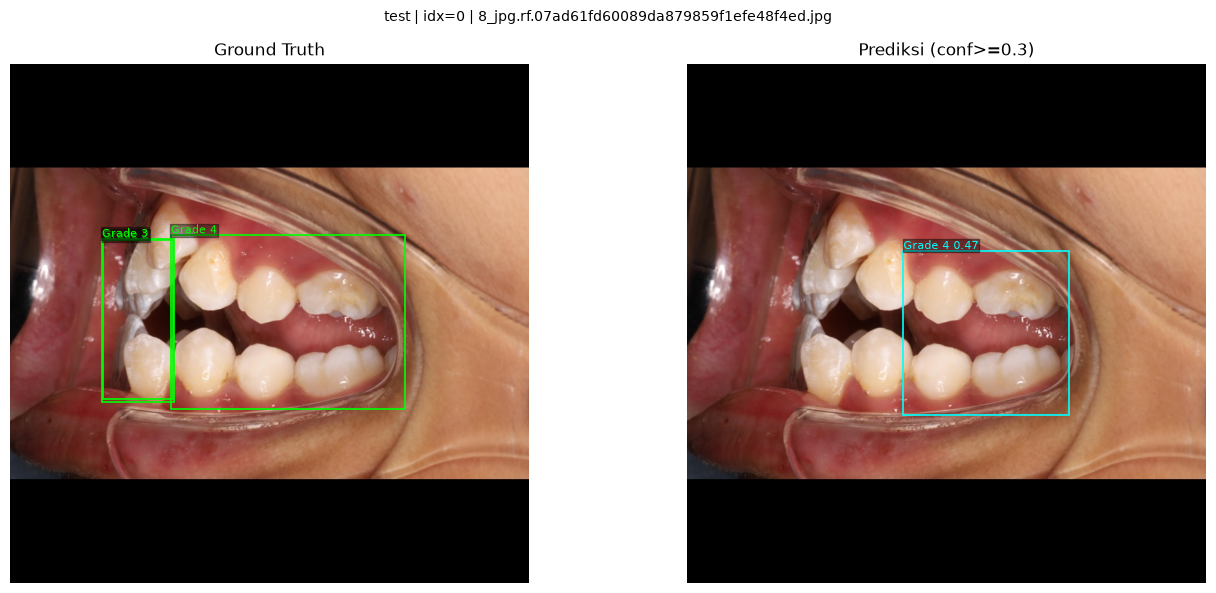

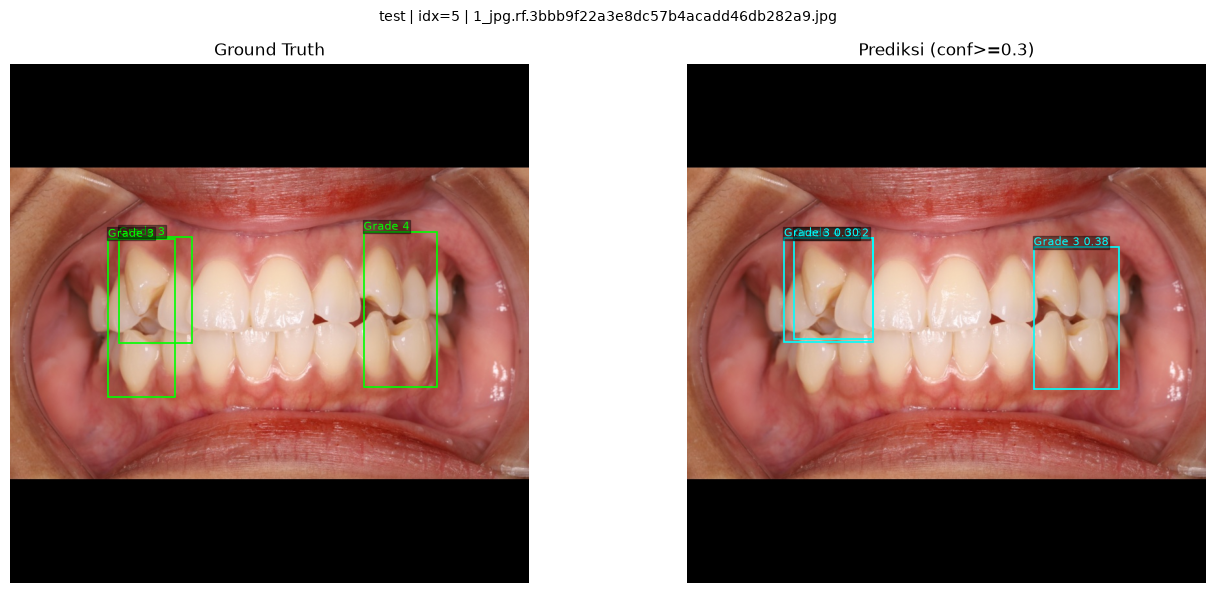

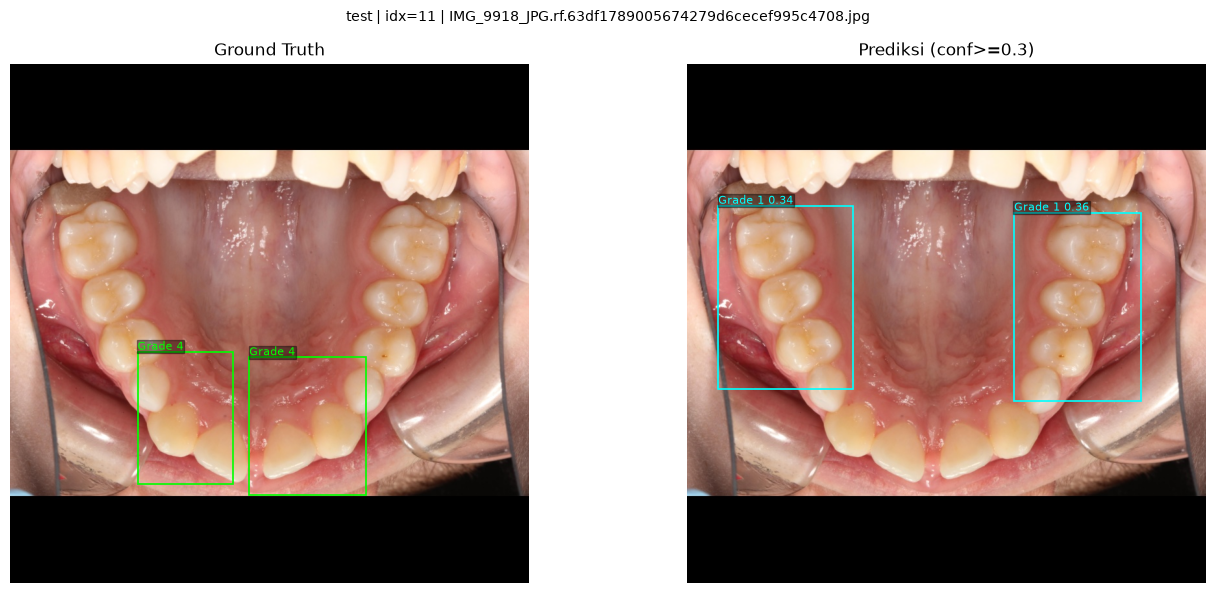

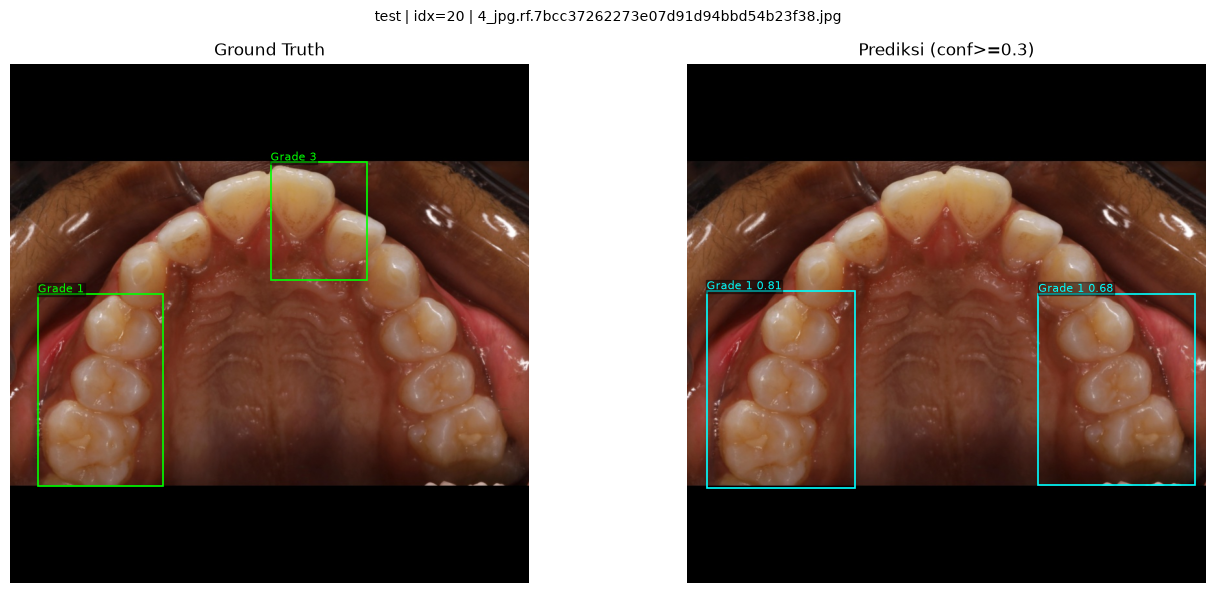

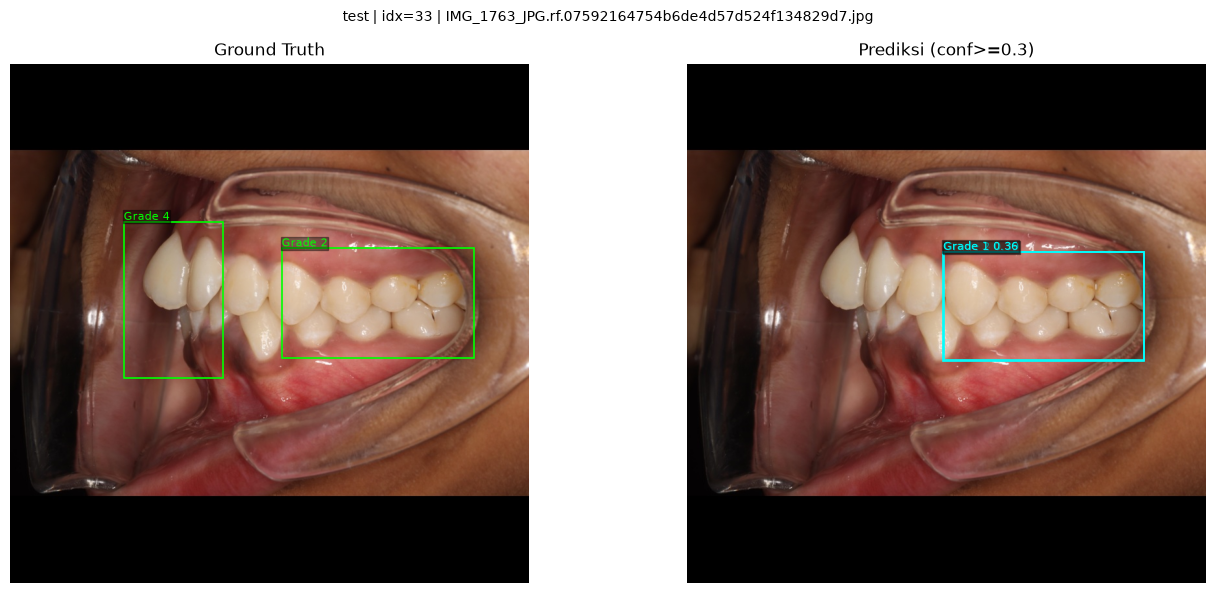

In [24]:
# beberapa sampel dari test set — hijau = ground truth, cyan = prediksi
for idx in [0, 5, 11, 20, 33]:
    show_prediction_vs_gt("test", idx, model_for_inference)


## Section 8: Transfer learning dari backbone `omni_coco`

Titik awal model diganti dari `yolo12n.pt` (pretrained COCO generik) ke checkpoint hasil training di `omni_coco` (`02_yolo_omni.ipynb`, 40 epoch, domain foto intraoral yang sama). Ultralytics otomatis pakai bobot backbone+neck yang match, cuma reset head klasifikasi buat 5 kelas Grade.

Hyperparameter training disamakan dengan Section 6 (`epochs=60, patience=20, degrees=10, copy_paste=0.3`) supaya perbandingan ke baseline tuned adil — satu-satunya variabel yang beda cuma titik awal bobotnya.

**Prasyarat:** jalankan dulu training di `02_yolo_omni.ipynb` (Section 3, sudah di-set 40 epoch) sampai selesai, baru cell di bawah ini bisa jalan.


In [25]:
OMNI_BACKBONE = Path("runs/detect/omni_yolo_runs/omni_40ep/weights/best.pt")
assert OMNI_BACKBONE.exists(), (
    f"Checkpoint omni belum ada di {OMNI_BACKBONE} — jalankan dulu training di 02_yolo_omni.ipynb"
)

model_yolo_transfer = YOLO(str(OMNI_BACKBONE))

results_transfer = model_yolo_transfer.train(
    data=str(yaml_path),
    epochs=60,
    patience=20,
    imgsz=800,
    batch=8,
    device=device,
    degrees=10,
    copy_paste=0.3,
    project="rf_yolo_runs",
    name="grade_only_omni_transfer",
)


New https://pypi.org/project/ultralytics/8.4.104 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.103 🚀 Python-3.13.2 torch-2.13.0 MPS (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/rf_yolo_grade/data.yaml, degrees=10, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/omni_yolo_runs/omni_40ep/weights/best.pt, momentum=0

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/60      4.61G      2.485      4.643       2.42         17        800: 100% ━━━━━━━━━━━━ 59/59 1.2it/s 50.7s0.9ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.3it/s 4.6s0.7ss
                   all         94        204    0.00735      0.798     0.0413     0.0136

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/60      4.44G      2.081      4.191      2.385         20        800: 0% ──────────── 0/59  0.7s

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/60      5.47G      1.892      3.775      2.059         17        800: 100% ━━━━━━━━━━━━ 59/59 1.6it/s 37.1s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.9it/s 3.1s0.6s
                   all         94        204      0.231      0.225     0.0419     0.0152

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      45/60      5.47G      1.319      1.895      1.584         20        800: 100% ━━━━━━━━━━━━ 59/59 1.6it/s 37.0s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.8it/s 3.4s0.7ss
                   all         94        204      0.367      0.407      0.323      0.161

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      46/60      5.44G      1.397      1.879      1.576         34        800: 0% ──────────── 0/59  0.8s

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      46/60      5.47G      1.355      1.839      1.585         26        800: 100% ━━━━━━━━━━━━ 59/59 1.6it/s 36.9s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.8it/s 3.4s0.7ss
                   all         94        204      0.306      0.498      0.314      0.149

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      47/60      5.44G      1.499      1.763      1.748         18        800: 0% ──────────── 0/59  0.8s

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      47/60      5.47G      1.312      1.804       1.54         23        800: 100% ━━━━━━━━━━━━ 59/59 1.6it/s 36.6s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.8it/s 3.4s0.7ss
                   all         94        204      0.389      0.348      0.318      0.153
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 27, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

47 epochs completed in 0.556 hours.
Optimizer stripped from /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/runs/detect/rf_yolo_runs/grade_only_omni_transfer/weights/last.pt, 5.6MB
Optimizer stripped from /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/runs/detect/rf_yolo_runs/grade_only_omni_transfer/weights/best.pt, 5.6MB

Validating /Use

### Evaluasi (transfer learning)

Dibandingkan ke Section 6 tuned (test: mAP50=40.86%, mAP50-95=20.09%, recall=0.461; Grade 3 AP=14.40%, Grade 5 AP=14.60%) — satu-satunya variabel beda cuma titik awal bobot (omni backbone vs `yolo12n.pt` generik).


In [26]:
metrics_transfer = model_yolo_transfer.val(data=str(yaml_path), split="test")

print(f"mAP50-95: {metrics_transfer.box.map:.4f}")
print(f"mAP50   : {metrics_transfer.box.map50:.4f}")
print(f"mAP75   : {metrics_transfer.box.map75:.4f}")


Ultralytics 8.4.103 🚀 Python-3.13.2 torch-2.13.0 CPU (Apple M2)
YOLOv12n summary (fused): 159 layers, 2,557,703 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 676.2±180.1 MB/s, size: 112.7 KB)
val: Scanning /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/data/rf_yolo_grade/labels/test.cache... 62 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 62/62 6.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 4.4s/it 17.5s8.4s8s
                   all         62        146      0.484      0.339      0.329      0.156
               Grade 1         14         20      0.455       0.55      0.472       0.24
               Grade 2         26         33      0.601      0.333      0.331      0.161
               Grade 3         26         32      0.292       0.25      0.208     0.0888
               Grade 4         34         44      0.501      0.386       0.36      0

In [27]:
# breakdown per Grade (transfer learning)
for idx, ap in enumerate(metrics_transfer.box.maps):
    print(f"{yolo_id_to_grade.get(idx, 'unknown')}: {ap * 100:.2f}")


Grade 1: 23.97
Grade 2: 16.07
Grade 3: 8.88
Grade 4: 13.37
Grade 5: 15.85


Confusion matrix: `runs/detect/rf_yolo_runs/grade_only_omni_transfer/confusion_matrix.png`.

## Catatan / temuan (transfer learning)

**Hipotesis tidak terkonfirmasi — secara umum lebih jelek dari baseline tuned, bukan sekadar "sama aja"**

| Metrik (test set) | Tuned (Section 6) | Transfer learning | Perubahan |
|---|---|---|---|
| mAP@50-95 | 20.09% | **15.63%** | -4.5pp (lebih jelek) |
| mAP@50 | 40.86% | **32.94%** | -7.9pp (lebih jelek) |
| mAP@75 | 17.64% | **13.64%** | -4.0pp (lebih jelek) |
| Precision | 0.411 | **0.484** | naik |
| Recall | 0.461 | **0.339** | turun signifikan |

Precision-nya naik, tapi recall turun jauh lebih banyak — hasil bersihnya tetap turun di semua metrik mAP. Model transfer learning jadi lebih "pelit" (lebih jarang nebak, tapi begitu nebak lebih sering benar) — bukan trade-off yang menguntungkan di sini.

**Breakdown per Grade (test, mAP@50-95) — cuma Grade 5 yang membaik**

| Grade | Tuned (Section 6) | Transfer learning | Perubahan |
|---|---|---|---|
| 1 | 30.42 | 23.97 | -6.5 (lebih jelek) |
| 2 | 25.20 | 16.07 | -9.1 (lebih jelek) |
| 3 | 14.40 | 8.88 | -5.5 (lebih jelek) |
| 4 | 15.85 | 13.37 | -2.5 (lebih jelek) |
| **5** | 14.60 | **15.85** | **+1.25 (satu-satunya yang membaik)** |

**Training early-stop di epoch 47** (patience=20 ke-trigger, model terbaik ketemu di epoch 27) — beda dari run tuned Section 6 yang jalan penuh 60 epoch tanpa early-stop. Artinya training dengan backbone omni ini **konvergen lebih cepat**, tapi mentok di titik yang lebih rendah — bukan cuma "belum selesai training".

**Dugaan penyebab (bukan bukti pasti, tapi konsisten dengan catatan awal saat section ini dibuat):**
- Sudah diperingatkan dari awal: bbox `omni_coco` itu kecil per-gigi (~1-3% luas gambar), sedangkan bbox dataset IOTN ini besar per-kuadran (~5-27%). Neck/FPN model omni kemungkinan sudah "terlanjur" ter-tuning ke skala objek kecil — ini bisa jadi bentuk *negative transfer*, bukan cuma netral.
- Fine-tuning di sini pakai learning rate & schedule yang sama persis dengan training dari nol (bukan LR lebih kecil yang lazim dipakai buat fine-tuning) — berpotensi "merusak" fitur backbone yang sudah bagus sebelum head sempat menyesuaikan, alih-alih memanfaatkannya secara halus.
- Grade 5 (satu-satunya yang membaik) berisi kondisi langka & sangat spesifik (hypodontia, impaksi, kraniofasial, dll) — mungkin kebetulan overlap paling dekat secara visual dengan sebagian fitur yang dipelajari dari `omni_coco` (mis. `TM`/tooth misalignment, `MR`/mandibular retrusion), meski ini spekulatif.

**Kesimpulan:** transfer learning dari backbone `omni_coco` (dengan setup langsung seperti ini) **bukan solusi yang tepat** untuk task ini — baseline tuned Section 6 (mulai dari `yolo12n.pt` generik) tetap yang terbaik sejauh ini. Kalau mau dicoba lagi, perlu perubahan lebih hati-hati (LR lebih kecil khusus fine-tuning, atau cuma freeze sebagian awal backbone) — bukan sekadar ganti checkpoint awal. Untuk sekarang, lebih masuk akal lanjut ke opsi lain yang belum dicoba: `yolo26n`/`yolo12s`, atau data tambahan yang ditargetkan ke Grade 3 & 5.


## Section 9: K-fold cross-validation

Bukan lagi buat "fix leakage" (sudah dibantah — lihat `05_iotn_grade_eda.ipynb`), murni buat dapat estimasi performa yang lebih stabil dari data yang terbatas ini. Daripada 1 test set tetap (62 gambar, gampang bias tergantung kebetulan pembagian), semua gambar (626, gabungan train+valid+test yang ada sekarang) dipool lalu dibagi jadi **5 fold seimbang per kelas Grade**. Model dilatih 5x (tiap kali 4 fold jadi train, 1 fold jadi val), hasilnya dirata-rata.

**Peringatan waktu:** ini 5x lebih lama dari 1 run training biasa (~40 menit/run tuned kemarin -> total bisa >3 jam). Cocok dijalankan di Colab kalau lokal kelamaan, sesuai rencana kamu.


In [8]:
import random
from collections import defaultdict

# pool semua gambar dari train+valid+test yang ada sekarang, re-index global
# (id COCO reset per split, jadi perlu di-unique-kan dulu sebelum digabung -- pola yang sama
# dipakai di 03_roboflow_preprocessing.ipynb waktu pool train+valid raw)
pooled_images = {}
pooled_annotations = []
img_counter = 0
ann_counter = 0
old_id_to_new = {}

for split in SPLITS:
    for img in coco_data[split]["images"]:
        new_id = img_counter
        img_counter += 1
        old_id_to_new[(split, img["id"])] = new_id
        rec = dict(img)
        rec["_src_split"] = split
        rec["id"] = new_id
        pooled_images[new_id] = rec
    for a in coco_data[split]["annotations"]:
        new_a = dict(a)
        new_a["id"] = ann_counter
        ann_counter += 1
        new_a["image_id"] = old_id_to_new[(split, a["image_id"])]
        pooled_annotations.append(new_a)

print(f"Total gambar dipool: {len(pooled_images)}")
print(f"Total anotasi dipool: {len(pooled_annotations)}")


Total gambar dipool: 626
Total anotasi dipool: 1417


### 9.1 Bagi jadi K fold — seimbang per kelas Grade

Greedy: proses kelas paling langka dulu, tiap gambar dari kelas itu dilempar ke fold yang saat ini paling sedikit instance kelas itu (tie-break: fold paling sedikit total gambar). Pola yang sama seperti stratifikasi 3-way di `03_roboflow_preprocessing.ipynb`, cuma digeneralisasi ke K fold.


In [15]:
K = 5
RNG_SEED = 42

img_to_grades = defaultdict(set)
for a in pooled_annotations:
    img_to_grades[a["image_id"]].add(category_id_to_grade[a["category_id"]])

grade_to_images = defaultdict(set)
for img_id, grades in img_to_grades.items():
    for g in grades:
        grade_to_images[g].add(img_id)

rng = random.Random(RNG_SEED)
fold_assignment = {}
fold_total_counts = [0] * K
fold_class_counts = defaultdict(lambda: [0] * K)

classes_sorted = sorted(grade_to_images.items(), key=lambda kv: len(kv[1]))

for gname, imgs in classes_sorted:
    unassigned = [i for i in imgs if i not in fold_assignment]
    rng.shuffle(unassigned)
    for img_id in unassigned:
        best_fold = min(range(K), key=lambda k: (fold_class_counts[gname][k], fold_total_counts[k]))
        fold_assignment[img_id] = best_fold
        fold_class_counts[gname][best_fold] += 1
        fold_total_counts[best_fold] += 1

# gambar tanpa anotasi grade sama sekali -> assign ke fold paling kecil biar total tetap rata
unassigned_no_grade = [i for i in pooled_images if i not in fold_assignment]
rng.shuffle(unassigned_no_grade)
for img_id in unassigned_no_grade:
    best_fold = min(range(K), key=lambda k: fold_total_counts[k])
    fold_assignment[img_id] = best_fold
    fold_total_counts[best_fold] += 1

assert len(fold_assignment) == len(pooled_images)
print("Jumlah gambar per fold:", fold_total_counts)
for gname, _ in classes_sorted:
    print(f"  {gname}: {fold_class_counts[gname]}")


Jumlah gambar per fold: [126, 125, 125, 125, 125]
  Grade 5: [24, 24, 24, 24, 24]
  Grade 1: [22, 22, 22, 22, 22]
  Grade 2: [34, 33, 33, 33, 33]
  Grade 3: [27, 27, 27, 27, 27]
  Grade 4: [18, 19, 19, 19, 18]


### 9.2 Bangun folder YOLO per fold, training loop 5x

Reuse `get_image_path`, `category_id_to_grade`, `convert_annotations_to_yolo_lines` yang sudah didefinisikan di Section 1-3. Tiap fold ditulis ke `data/rf_yolo_grade_kfold/fold_{i}/`, model & hasil run disimpan terpisah per fold (`grade_kfold_0` .. `grade_kfold_4`).


In [16]:
KFOLD_ROOT = Path("data/rf_yolo_grade_kfold")

anns_by_image = defaultdict(list)
for a in pooled_annotations:
    anns_by_image[a["image_id"]].append(a)

fold_results = []

for fold_idx in range(K):
    print(f"\n{'=' * 20} FOLD {fold_idx + 1}/{K} {'=' * 20}")

    fold_dir = KFOLD_ROOT / f"fold_{fold_idx}"
    img_train_dir = fold_dir / "images" / "train"
    img_val_dir = fold_dir / "images" / "val"
    lbl_train_dir = fold_dir / "labels" / "train"
    lbl_val_dir = fold_dir / "labels" / "val"
    for d in [img_train_dir, img_val_dir, lbl_train_dir, lbl_val_dir]:
        d.mkdir(parents=True, exist_ok=True)

    for img_id, img_rec in pooled_images.items():
        is_val = fold_assignment[img_id] == fold_idx
        img_dir = img_val_dir if is_val else img_train_dir
        lbl_dir = lbl_val_dir if is_val else lbl_train_dir

        src_path = get_image_path(img_rec["_src_split"], img_rec)
        dst_img_path = img_dir / img_rec["file_name"]
        shutil.copy(src_path, dst_img_path)

        anns = anns_by_image.get(img_id, [])
        lines = convert_annotations_to_yolo_lines(anns, img_rec["width"], img_rec["height"])
        dst_label_path = lbl_dir / (Path(img_rec["file_name"]).stem + ".txt")
        with open(dst_label_path, "w") as f:
            f.write("\n".join(lines))

    fold_yaml_content = f"""
path: {fold_dir.resolve()}
train: images/train
val: images/val

names:
"""
    for idx in sorted(yolo_id_to_grade.keys()):
        fold_yaml_content += f"  {idx}: {yolo_id_to_grade[idx]}\n"
    fold_yaml_path = fold_dir / "data.yaml"
    with open(fold_yaml_path, "w") as f:
        f.write(fold_yaml_content.strip())

    model_fold = YOLO("yolo12n.pt")
    model_fold.train(
        data=str(fold_yaml_path),
        epochs=60,
        patience=20,
        imgsz=800,
        batch=8,
        device=device,
        degrees=10,
        copy_paste=0.3,
        project="rf_yolo_runs",
        name=f"grade_kfold_{fold_idx}",
        verbose=False,
    )

    metrics_fold = model_fold.val(data=str(fold_yaml_path), split="val")
    fold_results.append({
        "fold": fold_idx,
        "mAP50-95": metrics_fold.box.map,
        "mAP50": metrics_fold.box.map50,
        "mAP75": metrics_fold.box.map75,
        "precision": metrics_fold.box.mp,
        "recall": metrics_fold.box.mr,
        **{f"AP_{yolo_id_to_grade[i]}": ap for i, ap in enumerate(metrics_fold.box.maps)},
    })
    print(f"Fold {fold_idx} selesai: mAP50-95={metrics_fold.box.map:.4f}")



==================== FOLD 1/5 ====================
New https://pypi.org/project/ultralytics/8.4.104 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.103 🚀 Python-3.13.2 torch-2.13.0 MPS (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/rf_yolo_grade_kfold/fold_0/data.yaml, degrees=10, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/60      4.44G      1.963      4.245      2.107         25        800: 100% ━━━━━━━━━━━━ 63/63 1.6it/s 40.2s0.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.1it/s 3.9s0.5ss
                   all        126        285    0.00714      0.829     0.0618     0.0232

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/60      4.38G      1.787       3.76      1.939         42        800: 0% ──────────── 0/63  0.8s

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/60      4.36G      1.813      3.854      1.996         13        800: 100% ━━━━━━━━━━━━ 63/63 1.7it/s 38.1s0.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.0it/s 4.0s0.5ss
                   all        126        285       0.43      0.137     0.0559     0.0187

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/60      4.37G      1.737      3.354      1.826         39        800: 0% ──────────── 0/63  0.7s

...

      58/60      4.38G      1.304      1.671      1.711         10        800: 100% ━━━━━━━━━━━━ 63/63 1.7it/s 36.8s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.0it/s 3.9s0.5ss
                   all        125        281      0.362      0.407       0.36      0.181

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      59/60      4.37G      1.269      1.663      1.727         19        800: 0% ──────────── 0/63  0.7s

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      59/60      4.38G      1.295      1.641      1.714         12        800: 100% ━━━━━━━━━━━━ 63/63 1.7it/s 36.8s0.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.0it/s 4.0s0.5ss
                   all        125        281      0.351      0.454      0.355      0.182

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      60/60      4.37G      1.323      1.737      1.732         16        800: 0% ──────────── 0/63  0.7s

/Users/benediktaaa/Documents/AML/dental-malocclusion/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      60/60      4.38G      1.272       1.64      1.678         18        800: 100% ━━━━━━━━━━━━ 63/63 1.7it/s 36.8s0.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.0it/s 4.0s0.5ss
                   all        125        281      0.343      0.478      0.358      0.182

60 epochs completed in 15.057 hours.
Optimizer stripped from /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/runs/detect/rf_yolo_runs/grade_kfold_4/weights/last.pt, 5.6MB
Optimizer stripped from /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/runs/detect/rf_yolo_runs/grade_kfold_4/weights/best.pt, 5.6MB

Validating /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/runs/detect/rf_yolo_runs/grade_kfold_4/weights/best.pt...
Ultralytics 8.4.103 🚀 Python-3.13.2 torch-2.13.0 MPS (Apple M2)
YOLOv12n summary (fused): 159 layers, 2,557,703 parameters, 0 gradients, 6.3 GFLOPs
                 Class     Ima

### 9.3 Agregasi hasil 5 fold


In [17]:
df_fold_results = pd.DataFrame(fold_results).set_index("fold")
df_fold_results


,mAP50-95,mAP50,mAP75,precision,recall,AP_Grade 1,AP_Grade 2,AP_Grade 3,AP_Grade 4,AP_Grade 5
fold,,,,,,,,,,
0,0.183347,0.372403,0.164003,0.382061,0.452025,0.251547,0.193794,0.175715,0.160066,0.135615
1,0.156157,0.307918,0.155032,0.377960,0.357319,0.207291,0.140825,0.125315,0.138196,0.169160
2,0.175704,0.336871,0.164921,0.392557,0.335591,0.188859,0.216455,0.163723,0.154328,0.155155
3,0.191078,0.382382,0.175071,0.393984,0.502195,0.292684,0.143956,0.138442,0.154355,0.225953
4,0.182369,0.364866,0.170975,0.427984,0.398219,0.256987,0.173039,0.138117,0.181470,0.162234


In [18]:
print("Rata-rata ± std lintas 5 fold:\n")
for col in df_fold_results.columns:
    print(f"  {col:16s}: {df_fold_results[col].mean():.4f} ± {df_fold_results[col].std():.4f}")


Rata-rata ± std lintas 5 fold:

  mAP50-95        : 0.1777 ± 0.0132
  mAP50           : 0.3529 ± 0.0303
  mAP75           : 0.1660 ± 0.0076
  precision       : 0.3949 ± 0.0197
  recall          : 0.4091 ± 0.0684
  AP_Grade 1      : 0.2395 ± 0.0415
  AP_Grade 2      : 0.1736 ± 0.0324
  AP_Grade 3      : 0.1483 ± 0.0207
  AP_Grade 4      : 0.1577 ± 0.0156
  AP_Grade 5      : 0.1696 ± 0.0339


### 9.4 Model final untuk dipakai (bukan model dari salah satu fold)

K-fold di sini murni buat **validasi metodologi & estimasi performa yang stabil** — bukan buat milih 1 model produksi dari 5 yang ada. Kalau angka rata-rata di atas sudah oke, model yang benar-benar dipakai selanjutnya sebaiknya dilatih ulang sekali lagi di **semua 626 gambar sekaligus** (gabungan semua fold, tanpa held-out), dengan hyperparameter yang sama (`epochs=60, patience=20, degrees=10, copy_paste=0.3`), supaya modelnya belajar dari data sebanyak mungkin.


## Catatan / temuan (k-fold)

**Semua 5 fold selesai tanpa error**, masing-masing 60 epoch penuh (tidak ada yang early-stop di `patience=20`).

**Angka rata-rata k-fold lebih rendah dari single-split `grade_only_tuned` — single-split kemarin ternyata agak optimis**

| Metrik | Single-split (`grade_only_tuned`) | K-fold (mean ± std) | Selisih |
|---|---|---|---|
| mAP@50-95 | 20.09% | **17.77% ± 1.32pp** | -2.3pp |
| mAP@50 | 40.86% | **35.29% ± 3.03pp** | -5.6pp |
| mAP@75 | 17.64% | **16.60% ± 0.76pp** | -1.0pp |
| Precision | 0.411 | **0.395 ± 0.020** | -0.016 |
| Recall | 0.461 | **0.409 ± 0.068** | -0.052 |

Ini mengonfirmasi dugaan awal kenapa k-fold dilakukan: test set tunggal (62 gambar) itu terlalu kecil buat dipercaya sebagai estimasi tunggal — kebetulan waktu itu kita dapat split yang sedikit menguntungkan. Angka k-fold (mAP50-95 ~17.8%) ini yang lebih representatif buat "performa asli" model dengan setup sekarang, bukan angka 20.1% yang dilaporkan sebelumnya.

**Variasi antar fold (std) itu sendiri adalah temuan penting**
mAP50-95 antar fold berkisar 15.6%-19.1% (spread ~3.5pp) hanya karena beda pembagian data — bukan beda model/setup. Ini menunjukkan **seberapa noisy evaluasi 1-split sebenarnya** buat dataset sekecil ini: kalau nasib baik/buruk pas milih test set, angka yang dilaporkan bisa geser beberapa poin persen tanpa perubahan apa pun di model. **Recall punya variasi relatif paling besar** (std 0.068 dari mean 0.409, ~17% relatif) dibanding precision (std 0.020 dari mean 0.395, ~5% relatif) — recall lebih nggak stabil lintas fold daripada precision.

**Breakdown per Grade — Grade 1 & 2 yang paling "koreksi turun", bukan Grade 3 yang jadi concern awal**

| Grade | Single-split tuned | K-fold (mean ± std) | Selisih |
|---|---|---|---|
| 1 | 30.42 | 23.95 ± 4.15 | **-6.5 (turun paling banyak)** |
| 2 | 25.20 | 17.36 ± 3.24 | **-7.8 (turun paling banyak)** |
| 3 | 14.40 | 14.83 ± 2.07 | +0.4 (nyaris sama) |
| 4 | 15.85 | 15.77 ± 1.56 | -0.1 (nyaris sama, paling stabil — std terkecil) |
| 5 | 14.60 | 16.96 ± 3.39 | +2.4 (malah lebih baik di rata-rata k-fold) |

Menarik — dugaan sebelumnya (Grade 3 "paling bermasalah") ternyata nggak terlihat separah itu begitu dirata-rata lintas 5 fold (malah nyaris identik ke single-split). Yang justru paling "terkoreksi turun" adalah **Grade 1 dan Grade 2** — single-split test set kemarin kebetulan berisi kombinasi gambar yang membuat model kelihatan lebih jago di dua kelas itu daripada rata-rata sebenarnya. **Grade 4 paling stabil** (std terkecil, 1.56) — konsisten dengan datanya yang paling banyak (435 instance).

**Catatan operasional (bukan soal kualitas model)**
Waktu training antar fold sangat timpang: fold 0-2 masing-masing ~0.73-0.75 jam (konsisten dengan run-run sebelumnya di MPS), tapi fold 3 = 5.17 jam dan fold 4 = 15.06 jam — semua tetap jalan di MPS lokal (bukan Colab), jadi kemungkinan besar mesin lokal mengalami throttling/sleep/gangguan lain selama run panjang tanpa pengawasan ini. Tidak mempengaruhi validitas hasil (training tetap selesai 60 epoch penuh setiap fold), cuma soal efisiensi waktu.

**Kesimpulan & langkah lanjut**
- **Angka yang sekarang dipakai sebagai acuan performa "sebenarnya": mAP@50-95 ≈ 17.8%, mAP@50 ≈ 35.3%** (bukan 20.1%/40.9% dari single-split kemarin) — k-fold ini yang lebih bisa dipercaya.
- Sesuai rencana Section 9.4: langkah berikutnya adalah **latih 1 model final di semua 626 gambar sekaligus** (hyperparameter sama), yang jadi model kandidat produksi — bukan model dari salah satu fold.
- Opsi eksperimen lain yang masih terbuka (belum dicoba): `yolo26n`/`yolo12s`, atau data tambahan yang ditargetkan ke kelas yang masih lemah (Grade 3 & 4, yang skornya paling rendah di rata-rata k-fold).
